In [8]:
# -*- coding: utf-8 -*-
"""
@author: Etienne Kras
"""

# generic imports
import sys
import os
import numpy as np
from pathlib import Path
import platform
import geopandas as gpd
import pandas as pd
import time
import geemap
import json
import geojson
import ee

project = "bathymetry"
ee.Initialize(project=project) # use the GEE project-id here

# specific imports
from typing import Any, Dict, List, Optional
from geojson import Feature, FeatureCollection, dump
from shapely.geometry import Polygon, MultiPolygon, shape
from dateutil.relativedelta import *
from google.cloud import storage
from logging import Logger, getLogger
from googleapiclient.discovery import build
from re import sub
from ctypes import ArgumentError
from functools import partial
from dateutil.parser import parse

# custom functionality import without requirement to pip install package
local_path = r"C:\Users\white_rn\Documents\GitHub\ee-packages-py"  # path to local GitHub clone
sys.path.append(local_path)
from eepackages.applications.bathymetry import Bathymetry
from eepackages import tiler

logger: Logger = getLogger(__name__)

*** Earth Engine *** Share your feedback by taking our Annual Developer Satisfaction Survey: https://google.qualtrics.com/jfe/form/SV_0JLhFqfSY1uiEaW?source=Init


In [9]:
sdb_folder = r"11209821-cmems-global-sdb"

# project toggles
if platform.system().startswith("Windows"):
    main_fol = Path(r"p:\\") / sdb_folder
else:
    main_fol = Path("/mnt/p") / sdb_folder  # name of the main local folder 
bucket = "cmems-sdb" # name of the Google Cloud Storage bucket to store files in the cloud
credential_file = main_fol / "00_miscellaneous" / "KEYS" / "bathymetry-543b622ddce7.json" # Cloud Storage credential key
output_fol = r"01_intertidal/02_data/04_calibrated" # name of the overall project
aoi_fol = r"00_miscellaneous/AOI_upscale" #AOIs
mask_fol = r"00_miscellaneous/Feasibility_maps" # masks
project_name = "AOI_WestEurope" # name of the project AoI
draw_AoI = 0 # toggle 1 to draw AoI, 0 to load

# composite image toggles
mode = "intertidal_improved_100m_upscaled" # specify mode, either "intertidal" or "subtidal"
start_date = "2021-01-01" # start date of the composites
stop_date = "2022-01-01" # end date of the composites
compo_int = 12 # composite interval [months]
compo_len = 12 # composite length [months]
scale = 100  # output resolution of the image [m]
crs = "EPSG:4326" # output projection of the image

# tiling options
zoomed_list = [9, 10, 11] # list with zoom levels to be inspected
sel_tile = 1 # idx of chosen tile level in zoomed_list (inspect the map to chose it accordingly)
# note, see https://www.openearth.nl/rws-bathymetry/2019.html; Z9 is optimal size..

# load google credentials, if specified
if not credential_file == "":  
    os.environ["GOOGLE_APPLICATION_CREDENTIALS"] = str(credential_file)

# load GTSM & gebco data
gtsm_col = ee.FeatureCollection('projects/bathymetry/assets/gtsm_waterlevels')
gebco_image = ee.Image('projects/bathymetry/assets/gebco_2023_hat_lat')

### Retrieving the global intertidal processing area

In [6]:
# draw or load Area of Interest (AoI)

# TODO: take center of AOI input file if present, put in random coordinate and let user find a place and draw a polygon
# TODO: fix horizontal tiling error (DOS) in API (to use multiple tiles) or move to single polygon run if AoI crosses multiple tiles
Map = geemap.Map(center=(54.2, 6.7), zoom=8) # initialize map with base in Hudayriat

if draw_AoI == 1:
    print("Please draw a polygon somewhere in a water body") # identifier
if draw_AoI == 0:
    # open AoI
    print("Loading and visualizing AoI") #identifier
    #AoIee = geemap.geojson_to_ee(os.path.join(main_fol,'AOI',project_name+'.geojson'))

    with open(main_fol / aoi_fol / (project_name + ".geojson"), 'r') as f:
        contents = geojson.loads(f.read())
    AoIee = ee.Geometry.MultiPolygon(contents["features"][0]["geometry"]["coordinates"])

    Map.addLayer(AoIee, {}, "AoI")

Map # show map

Loading and visualizing AoI


Map(center=[54.2, 6.7], controls=(WidgetControl(options=['position', 'transparent_bg'], widget=SearchDataGUI(c…

In [7]:
# (re)construct the AoI
if draw_AoI == 1:
    
    print("Constructing AoI from drawn polygon") # identifier
    
    # get AoI 
    AoIee = ee.FeatureCollection(Map.draw_features) # make featurecollection
    AoI = Polygon(AoIee.getInfo()["features"][0]["geometry"]["coordinates"][0]) # create AoI shapefile

    # export AoI
    features = []
    features.append(Feature(geometry=AoI, properties={"AoI": project_name}))
    AoIjson = FeatureCollection(features)
    with open(main_fol / "AOI" / (project_name + ".geojson"), "w") as f: # geojson
        dump(AoIjson, f)
    gdr = gpd.GeoDataFrame({"properties":{"AoI": project_name}, "geometry": AoI}, crs="EPSG:4326") #shp
    gdr.to_file(main_fol / "AOI" / (project_name+".shp"))
    bounds = ee.Geometry.Polygon([[[a,b] for a, b in zip(*AoI.exterior.coords.xy)]])
    
if draw_AoI == 0:
    print("Reconstructing AoI from loaded file")
    # get AoI
    with open(main_fol / aoi_fol / (project_name+".geojson")) as f:
        AoIjson = geojson.load(f)
    # try: # drawn polygon in this script
    #     AoI = Polygon(AoIjson["features"][0]["geometry"]["coordinates"]) 
    # except: # drawn in QGIS / ArcGIS and written to geojson there (client file)
    #     AoI = Polygon(AoIjson["features"][0]["geometry"]["coordinates"][0])
    # bounds = ee.Geometry.Polygon([[[a,b] for a, b in zip(*AoI.exterior.coords.xy)]])
    bounds = ee.Geometry.MultiPolygon(AoIjson["features"][0]["geometry"]["coordinates"])

    # make list of multipolygons a single one
    # MPL = []
    # for i in AoIjson["features"]:
    #     for j in i["geometry"]["coordinates"]:
    #         MPL.append(j)

    # bounds = ee.Geometry.MultiPolygon(MPL)

Reconstructing AoI from loaded file


### Coupling the global intertidal processing area (mask) to the AOI

In [8]:
# make the AoI a gdf dataframe (takes about 5 min), using geojson
gdf_AOI = gpd.GeoDataFrame.from_features(AoIjson)

# retrieve the (buffered) global coastal intertidal mask (geojson)
# allfiles = os.listdir(os.path.join(main_fol, mask_fol, "Buffered\AOI_results"))
# dfs = []
# for i in allfiles:
#     for j in os.listdir(os.path.join(main_fol, mask_fol, "Buffered\AOI_results", i)):
#         if "result.geojson" in j:
#             print(j) 
#             #open geojson
#             with open(os.path.join(main_fol, mask_fol, "Buffered\AOI_results", i, j)) as f:
#                 #data = geojson.load(f)
#                 df = gpd.read_file(f)

#                 # inner join to match the AOI and mask
#                 df_joined = df.sjoin(gdf_AOI, how="inner")

#                 dfs.append(df_joined) # append to list

# # concat the geodfs list
# gdfs = gpd.GeoDataFrame(pd.concat(dfs, ignore_index=True)) 

In [9]:
# retrieve the (buffered) global coastal intertidal mask (geojson), using parquet
allfiles = os.listdir(main_fol / mask_fol / "2024")#r"2023\Buffered\AOI_results")
for i in allfiles:
    if "gebco" in i and '.parquet' in i and "minus2" in i:
        print(i)
        # read parquet file
        df_buf = gpd.read_parquet(main_fol / mask_fol / "2024" / i)#r"2023\Buffered\AOI_results" / i) --> 1.1 million rows (polygons)

        # filter the data (3 = original, 2 = L-W mask, 1 = <HAT >LAT pixel)
        df_org = df_buf[df_buf["pixel_value"] == 3.0] # select only the pixels with value 3.0 (original) --> 415 k rows (polygons)

        # inner join to match the AOI and mask
        gdfs_org = df_buf.sjoin(gdf_AOI, how="inner")

gebco_2024_latminus2_merge_result.parquet


In [10]:
# make a multipolygon
#df_mp_buf = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(df_buf.geometry))]}) #gdfs_buf
df_mp_org = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(gdfs_org.geometry))]}) #gdfs_org

# make a ee.Geometry.MultiPolygon to have bounds
# data_buf = json.loads(df_mp_buf.to_json())
# feature_collection_buf = geojson.FeatureCollection(data_buf['features'])
# bounds_buf = ee.Geometry.MultiPolygon(feature_collection_buf["features"][0]["geometry"]["coordinates"])

# make a ee.Geometry.MultiPolygon to have bounds
data_org = json.loads(df_mp_org.to_json())
feature_collection_org = geojson.FeatureCollection(data_org['features'])
bounds_org = ee.Geometry.MultiPolygon(feature_collection_org["features"][0]["geometry"]["coordinates"])

# add to map
#Map.addLayer(bounds_org, {}, "global intertidal feasibility mask")

### Tiling the AOI

In [11]:
# function for tiling the AoI and showing it on the map
def add_tile_bounds(zoom):
    tiled = tiler.get_tiles_for_geometry(bounds, zoom)
    Map.addLayer(tiled.style(width=max(1, 10 - zoom), fillColor= "00000022"), {}, "tiles " + str(zoom))

    return(tiled)

In [12]:
# for LAT-2

#Z9
# tiles9_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[0]))
# tiles9_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[0]))

#Z10
# tiles10_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[1]))
tiles10_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[1]))

# Z11 
# tiles11_buf = tiler.get_tiles_for_geometry(bounds_buf, ee.Number(zoomed_list[2])) 
# tiles11_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[2])) 

In [13]:
print("buffered")
# print(tiles9_buf.size().getInfo())
# print(tiles10_buf.size().getInfo())
# print(tiles11_buf.size().getInfo())
print("original")
# print(tiles9_org.size().getInfo())
print(tiles10_org.size().getInfo())
# print(tiles11_org.size().getInfo())

buffered
original
187


### Coupling the global intertidal processing area (mask) to the global boxes

In [14]:
# load geojon for ICC ref regions
ref_regions = gpd.read_file(os.path.join(main_fol / "00_miscellaneous" / "IPCC_regions", "IPCC-WGI-reference-regions-v4.geojson"))
ref_regions.shape, ref_regions.head()

((58, 6),
   id      Continent  Type               Name Acronym  \
 0  0          POLAR  Land  Greenland/Iceland     GIC   
 1  1  NORTH-AMERICA  Land  N.W.North-America     NWN   
 2  2  NORTH-AMERICA  Land  N.E.North-America     NEN   
 3  3  NORTH-AMERICA  Land    W.North-America     WNA   
 4  4  NORTH-AMERICA  Land    C.North-America     CNA   
 
                                             geometry  
 0  POLYGON ((-10.00000 62.00000, -10.43750 62.000...  
 1  POLYGON ((-105.00000 50.00000, -105.43860 50.0...  
 2  POLYGON ((-50.00000 50.00000, -50.44000 50.000...  
 3  POLYGON ((-130.00000 50.00000, -129.56140 50.0...  
 4  POLYGON ((-90.00000 50.00000, -90.00000 49.561...  )

In [15]:
# retrieve the (buffered) global coastal intertidal mask (geojson), using parquet
allfiles = os.listdir(main_fol / mask_fol / "2024")#r"2023\Buffered\AOI_results")
for i in allfiles:
    if "gebco" in i and '.parquet' in i and "minus2" in i:
        print(i)
        # read parquet file
        df_buf = gpd.read_parquet(main_fol / mask_fol / "2024" / i)#r"2023\Buffered\AOI_results" / i) --> 1.1 million rows (polygons)

        # filter the data (3 = original, 2 = L-W mask, 1 = <HAT >LAT pixel)
        df_org = df_buf[df_buf["pixel_value"] == 3.0] # select only the pixels with value 3.0 (original) --> 415 k rows (polygons)

        # inner join to match the AOI and mask
        # gdfs_buf = df_buf.sjoin(gdf_AOI, how="inner")
        gdfs_org = df_org.sjoin(ref_regions, how="inner")

        # remove duplicates (with different AOIs we do not want to replicate the feasibility areas)
        gdfs_org_rd = gdfs_org[~gdfs_org.index.duplicated(keep='first')]

gebco_2024_latminus2_merge_result.parquet


In [16]:
# loop over the ref regions
for idx, i in enumerate(gdfs_org_rd["Acronym"].unique()):
    if i == "NEN" or i == "NWN" or i == "RAR" or i == "GIC" or i == "NEU" or i == "EAS": 
        print("%s of %s"%(idx, len(gdfs_org_rd["Acronym"].unique())), i) # print the progress
        gdfs_org_rd_fil = gdfs_org_rd[gdfs_org_rd["Acronym"] == i] # select the ref region

        # split dataframe if too large
        if gdfs_org_rd_fil.shape[0] > 15000:
            # Define a function to split the DataFrame
            def split_dataframe(df, chunk_size):
                num_chunks = int(np.ceil(len(df) / chunk_size))
                return [df[i*chunk_size:(i+1)*chunk_size] for i in range(num_chunks)]
            
            # Split the DataFrame into chunks of 10,000 rows
            chunk_size = 10000
            df_chunks = split_dataframe(gdfs_org_rd_fil, chunk_size)

        else: # if small enough (< 15000)
            df_chunks = [gdfs_org_rd_fil]

        for ids, dfs in enumerate(df_chunks):
            if len(df_chunks) > 1:
                print("chunk %s of %s" %(ids+1, len(df_chunks)))

            df_mp_org = gpd.GeoDataFrame({'geometry': [MultiPolygon(list(dfs.geometry))]}) # make a multipolygon
            
            #make a ee.Geometry.MultiPolygon to have bounds
            data_org = json.loads(df_mp_org.to_json())
            feature_collection_org = geojson.FeatureCollection(data_org['features'])
            bounds_org = ee.Geometry.MultiPolygon(feature_collection_org["features"][0]["geometry"]["coordinates"])

            # compute the tiles
            tiles_org = tiler.get_tiles_for_geometry(bounds_org, ee.Number(zoomed_list[sel_tile]))

            # export selected tiles (represented by zoom level) to geojsons
            # note, adjust sel_tile accordingly 
            if not os.path.exists(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i): # make folder to export
                os.mkdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)

            try: 
                for idx, tile in enumerate(tiles_org.getInfo()["features"]):
                    tile_pol = Polygon(tile['geometry']['coordinates'][0]) # create tile polygon
                    tile_name = "z%s_x%s_y%s"%(tile["properties"]["zoom"], int(float(tile["properties"]["tx"])), int(float(tile["properties"]["ty"])))

                    features = []
                    features.append(Feature(geometry=tile_pol, properties={"name": tile_name, "id":tile['id'], "tx":float(tile["properties"]["tx"]), "ty":float(tile["properties"]["ty"]), "zoom":int(float(tile["properties"]["zoom"]))}))
                    feature_collection = FeatureCollection(features)
                    feature_collection.crs = {"type": "name","properties": {"name": "epsg:3857"}} # default EE projection
                    with open(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / (tile_name + ".geojson"), "w") as f: # geojson
                        dump(feature_collection, f) 
            except Exception as e:
                print(e)

26 of 53 NEN
chunk 1 of 6
chunk 2 of 6


: 

: 

In [ ]:
# how many boxes do we have?
boxes = []
for i in os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world"):
    print(i, len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)))
    boxes.append(len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)))

# total number of boxes to run
print("Total number of boxes")
sum(boxes)

ARO 1507
ARP 363
ARS 47
BOB 45
CAF 71
CAR 464
CAU 96
CNA 47
EAN 1552
EAO 21
EAS 1061
EAU 157
EEU 7
EIO 200
ENA 733
EPO 409
ESAF 174
GIC 4095
MDG 211
MED 1130
NAO 86
NAU 507
NCA 306
NEAF 108
NEN 5799
NES 169
NEU 2210
NPO 406
NSA 219
NWN 2968
NWS 177
NZ 232
RAR 4116
RFE 960
SAH 238
SAO 12
SAS 325
SAU 346
SCA 418
SEA 2599
SEAF 85
SES 181
SIO 62
SOO 225
SPO 630
SSA 572
SWS 258
WAF 207
WAN 1373
WCA 103
WCE 325
WNA 174
WSAF 136
Total number of boxes


38922

WCE
{"$schema": "https://proj.org/schemas/v0.6/projjson.schema.json", "type": "GeographicCRS", "name": "WGS 84", "datum_ensemble": {"name": "World Geodetic System 1984 ensemble", "members": [{"name": "World Geodetic System 1984 (Transit)"}, {"name": "World Geodetic System 1984 (G730)"}, {"name": "World Geodetic System 1984 (G873)"}, {"name": "World Geodetic System 1984 (G1150)"}, {"name": "World Geodetic System 1984 (G1674)"}, {"name": "World Geodetic System 1984 (G1762)"}, {"name": "World Geodetic System 1984 (G2139)"}], "ellipsoid": {"name": "WGS 84", "semi_major_axis": 6378137, "inverse_flattening": 298.257223563}, "accuracy": "2.0", "id": {"authority": "EPSG", "code": 6326}}, "coordinate_system": {"subtype": "ellipsoidal", "axis": [{"name": "Geodetic latitude", "abbreviation": "Lat", "direction": "north", "unit": "degree"}, {"name": "Geodetic longitude", "abbreviation": "Lon", "direction": "east", "unit": "degree"}]}, "scope": "Horizontal component of 3D system.", "area": "World.",

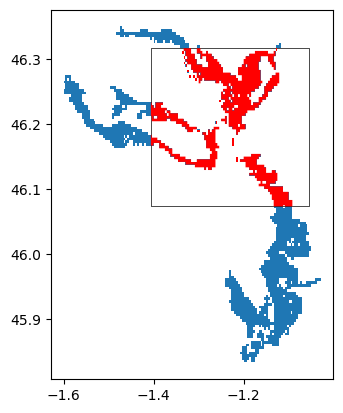

In [ ]:
# building a df of boxes, with some additional characteristics (perc of the area covered by the mask, area acronym, etc.)
df_boxes = pd.DataFrame()
for i in os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world"):
    if i == "WCE":
        print(i)
        for idx, j in enumerate(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i)):
            if j == "z10_x508_y363.geojson":
                print('% s of %s' % (idx, len(os.listdir(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i))), flush=True, end="\r")

                # open the box as gpd
                with open(main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / j) as f:
                    df = gpd.read_file(f)
                    df["path"] = main_fol / "00_miscellaneous" / "AOI_polygons_world" / i / j
                    df["ref_region"] = i

                    # Perform spatial join are areas intersecting with the mask (as pre-filter)
                    joined_gdf = df_org.sjoin(df.to_crs("EPSG:4326"), how='inner', predicate='intersects') 
                    
                    # Intersection of polygons to the bounding box of the tile
                    cropped_gdf = gpd.overlay(joined_gdf, df.to_crs("EPSG:4326"), how='intersection')

                    # erode the cropped_gdf
                    # bbox 50 m larger
                    # cropped_gdf 50 m smaller
                    print(cropped_gdf.to_crs)
                    cropped_gdf = cropped_gdf.buffer(-0.0001)

                    # make example plot
                    ax = joined_gdf.plot()
                    df.to_crs("epsg:4326").plot(ax=ax, linewidth=0.5, edgecolor='black', facecolor='none')
                    cropped_gdf.plot(ax=ax, facecolor='red')

                    # calculate the area
                    df["area_perc"] = round((sum(cropped_gdf.geometry.area)/df.to_crs("epsg:4326").area)*100,2) # percentage of the area covered by the mask

                    # merge in
                    df_boxes = pd.concat([df_boxes, df], ignore_index=True)   

# save the df
#df_boxes.to_csv(main_fol / "00_miscellaneous" / "AOI_polygons_world" / "df_boxes_world_%s.csv" % zoomed_list[sel_tile]) 

In [ ]:
df_boxes.to_csv(main_fol / "00_miscellaneous" / "AOI_polygons_world" / ("df_boxes_world_Z" + str(zoomed_list[sel_tile]) + ".csv")) 

In [ ]:
df_boxes.head()

,name,id,tx,ty,zoom,geometry,path,ref_region,area_perc
0,z10_x561_y116,2195,561.0,116.0,10,"POLYGON ((1917652.166 15458624.601, 1956787.92...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,2.32
1,z10_x667_y108,13635,667.0,108.0,10,"POLYGON ((6066042.565 15771710.669, 6105178.32...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,1.29
2,z10_x566_y141,2760,566.0,141.0,10,"POLYGON ((2113330.958 14480230.639, 2152466.71...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.71
3,z10_x545_y140,491,545.0,140.0,10,"POLYGON ((1291480.030 14519366.397, 1330615.78...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,22.14
4,z10_x644_y109,11152,644.0,109.0,10,"POLYGON ((5165920.120 15732574.910, 5205055.87...",p:\11209821-cmems-global-sdb\00_miscellaneous\...,ARO,0.42


In [ ]:
df_boxes.shape

(38922, 9)

In [ ]:
# TODO: sort the dataframe in the order as wished for the processing routine

# improvements
# TODO: if 1 pixel is is neighboured by 2 pixels at most, skip. Max we have 4 pixels or 9 is we count diagonally --> can put to Mario..
    # buffered (added with pixel along coastline)
    # original (default output)
    # minimal (red. with pixels)
# TODO: filter 80 deg north and 73 deg south?

0.0005034722222229052

## Filtering of boxes by Ruben White

### 0. Packages

In [1]:
# Packages
import pandas as pd
import geopandas as gpd
import os
from shapely import wkt
from shapely.geometry import box
import matplotlib.pyplot as plt
import contextily as ctx

C:\Users\white_rn\AppData\Local\Temp\ipykernel_12716\3499821778.py:3: UserWarning: Shapely 2.0 is installed, but because PyGEOS is also installed, GeoPandas will still use PyGEOS by default for now. To force to use and test Shapely 2.0, you have to set the environment variable USE_PYGEOS=0. You can do this before starting the Python process, or in your code before importing geopandas:

import os
os.environ['USE_PYGEOS'] = '0'
import geopandas

In a future release, GeoPandas will switch to using Shapely by default. If you are using PyGEOS directly (calling PyGEOS functions on geometries from GeoPandas), this will then stop working and you are encouraged to migrate from PyGEOS to Shapely 2.0 (https://shapely.readthedocs.io/en/latest/migration_pygeos.html).
  import geopandas as gpd


### 1. Settings

In [2]:
# Settings
dir_path_main= r'p:/11209821-cmems-global-sdb'
zoomed_list = [9, 10, 11]
sel_tile = 1

# File paths
file_path_boxes_csv = os.path.join(dir_path_main, '00_miscellaneous', 'AOI_polygons_world', 'df_boxes_world_Z{}.csv'.format(zoomed_list[sel_tile]))
file_path_mask_parquet = os.path.join(dir_path_main, '00_miscellaneous', 'Feasibility_maps', '2024', 'gebco_2024_latminus2_merge_result.parquet')
file_path_stations_geojson = r'p:\11209821-cmems-global-sdb\01_intertidal\02_data\02_gtsm_files\gtsm_stations.geojson'

# Load boxes
df_boxes = pd.read_csv(file_path_boxes_csv, index_col=0)
df_boxes['geometry'] = df_boxes['geometry'].apply(wkt.loads)
gdf_boxes = gpd.GeoDataFrame(df_boxes, geometry='geometry', crs="EPSG:3857")

# Load mask
gdf_mask = gpd.read_parquet(file_path_mask_parquet)
gdf_mask = gdf_mask.to_crs("EPSG:3857")
gdf_mask = gdf_mask[gdf_mask["pixel_value"] == 3.0]

# Load GTSM stations
gdf_stations = gpd.read_file(file_path_stations_geojson)
gdf_stations = gdf_stations.to_crs("EPSG:3857")

In [15]:
# Create a bounding box
#bbox = box(-20, 35, 40, 70) # Europe
#bbox = box(-140, 40, -50, 80) # Canada
#bbox = box(3.0, 50.5, 7.5, 53.7) # Netherlands
bbox = box(4, 52.7, 5, 53.7) # Netherlands
#bbox = box(4.5, 53.0, 7.5, 54.0) # Wadden Sea
#bbox = box(-99.5, 69.0, -99.0, 69.5) # King William Island

# Create bbox geodataframe
gdf_bbox = gpd.GeoDataFrame(geometry=[bbox], crs="EPSG:4326").to_crs("EPSG:3857")

### 2. Filter based on morpohlogical erosion-dilation mask

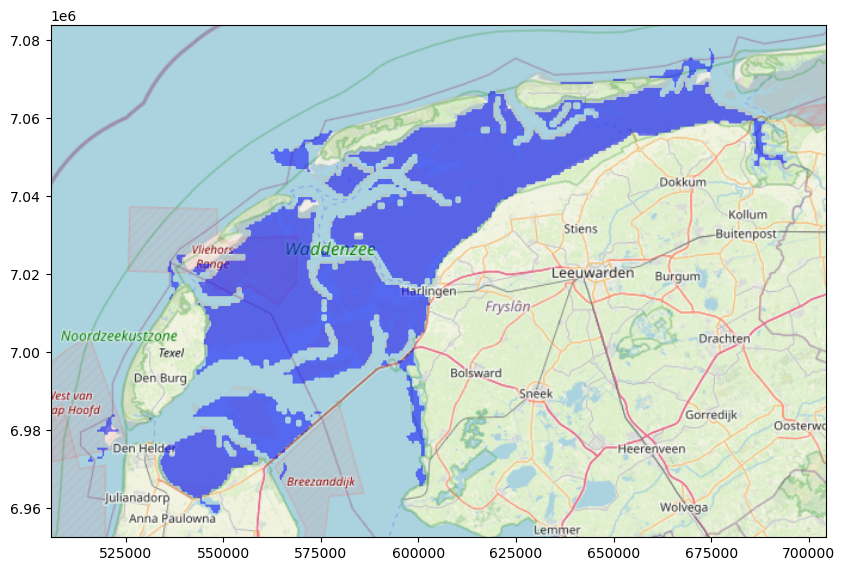

In [23]:
# Clip mask
gdf_mask_ = gdf_mask[gdf_mask.intersects(gdf_bbox.unary_union)].copy()

# Morphological erosion-dilation of mask with a buffer (1 pixel)
gdf_mask_['geometry'] = gdf_mask_['geometry'].buffer(-500)
#gdf_mask_['geometry'] = gdf_mask_['geometry'].buffer(500)

# Plot maks
fig, ax = plt.subplots(figsize=(10, 10))
gdf_mask_.plot(ax=ax, facecolor='blue', alpha=0.5)
ctx.add_basemap(ax, crs=gdf_mask_.crs, attribution='', source=ctx.providers.OpenStreetMap.Mapnik)

### 3. Filter based on distance to stations

In [24]:
# Create a kd-tree for the stations
from scipy.spatial import cKDTree
tree = cKDTree(gdf_stations['geometry'].apply(lambda x: (x.x, x.y)).tolist())

# Find the nearest station and its distance
def find_nearest_station(row):
    dist, idx = tree.query((row['geometry'].centroid.x, row['geometry'].centroid.y)) 
    return pd.Series([idx, dist/1000])

# Find the nearest station
gdf_boxes[['idx_nearest_station', 'distance_nearest_station']] = gdf_boxes.apply(find_nearest_station, axis=1)

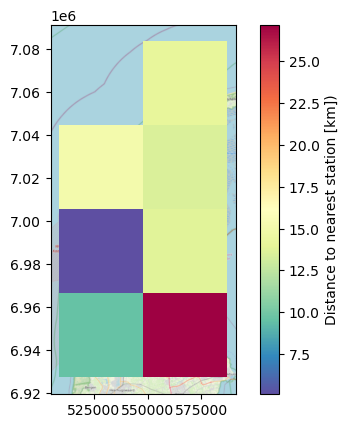

In [25]:
# Clip boxes
gdf_boxes_ = gdf_boxes[gdf_boxes.intersects(gdf_bbox.unary_union)].copy()

# Plot boxes
fig, ax = plt.subplots()
gdf_boxes_.plot(ax=ax, column='distance_nearest_station', cmap='Spectral_r', legend=True, legend_kwds={'label': "Distance to nearest station [km])"})
ctx.add_basemap(ax=ax, crs=gdf_boxes_.crs, attribution='', source=ctx.providers.OpenStreetMap.Mapnik)